# Staff management strategy based on flight information to reduce queues at passport control

This notebook develops a data-driven decision-support framework for airport passport control, with a focus on non-EU arrivals. The workflow combines:

- flight-level demand prediction,
- discrete-time queue simulation,
- and policy comparison for staffing decisions.

The goal is to show how operational planners can use scheduled flight information to anticipate congestion and dynamically allocate border-control officers in ways that reduce queues and passenger waiting times while keeping resource usage efficient.

## Problem framing

Long queues at airport passport control are increasingly common, especially for non-EU passengers. This creates an operational need for better staffing decisions based on better short-term demand visibility and staffing allocation.

We will model the problem in four steps:

1. Generate realistic synthetic flight-level data for arriving non-EU traffic.
2. Train a machine-learning model to predict the number of passengers who will reach passport control in each 15-minute interval.
3. Simulate the passport-control queue under different staffing policies.
4. Compare waiting-time and utilization outcomes across policies.

The notebook is designed to be easy to adapt to real airport data later.

In [322]:
import math
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpy

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

plt.style.use('ggplot')
np.random.seed(42)

## Synthetic airport arrivals data

In a real deployment, airports would use operational data such as:

- scheduled and actual arrival times,
- aircraft type and capacity,
- route origin,
- historical load factors,
- share of non-EU passengers,
- walking times from gate to passport control,
- and observed service rates for non-EU passenger processing.

Here we create a synthetic but realistic dataset that mimics those drivers.

In [323]:
AIRLINES = ['Aegean', 'Lufthansa', 'Ryanair', 'Turkish', 'Emirates', 'Wizz', 'easyJet']
REGIONS = ['Middle East', 'North Africa', 'UK', 'Balkans', 'Asia', 'Other']
AIRCRAFT = ['A320', 'A321', 'B737', 'B787', 'A330']
DAY_TYPES = ['Weekday', 'Weekend']

CAPACITY_MAP = {'A320': 180, 'A321': 220, 'B737': 189, 'B787': 280, 'A330': 260}
REGION_NON_EU_SHARE = {
    'Middle East': 0.95,
    'North Africa': 0.98,
    'UK': 0.75,
    'Balkans': 0.85,
    'Asia': 0.99,
    'Other': 0.80,
}

def generate_flights(n_days=120, min_flights=18, max_flights=34, seed=42):
    rng = np.random.default_rng(seed)
    records = []
    start_date = pd.Timestamp('2025-01-01')

    for d in range(n_days):
        date = start_date + pd.Timedelta(days=d)
        is_weekend = date.dayofweek >= 5
        n_flights = rng.integers(min_flights, max_flights + 1)

        for flight_idx in range(n_flights):
            aircraft = rng.choice(AIRCRAFT, p=[0.28, 0.24, 0.24, 0.12, 0.12])
            region = rng.choice(REGIONS, p=[0.18, 0.16, 0.20, 0.14, 0.10, 0.22])
            airline = rng.choice(AIRLINES)

            scheduled_hour = int(np.clip(rng.normal(13.5, 5.0), 0, 23))
            scheduled_minute = int(rng.choice([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]))
            scheduled_arrival = pd.Timestamp(date.year, date.month, date.day, scheduled_hour, scheduled_minute)

            delay_minutes = int(np.clip(rng.normal(12, 18), -10, 75))
            actual_arrival = scheduled_arrival + pd.Timedelta(minutes=delay_minutes)

            capacity = CAPACITY_MAP[aircraft]
            base_load_factor = 0.84 + (0.03 if is_weekend else 0.0) + rng.normal(0, 0.06)
            load_factor = float(np.clip(base_load_factor, 0.55, 0.99))

            non_eu_share = REGION_NON_EU_SHARE[region] + rng.normal(0, 0.04)
            non_eu_share = float(np.clip(non_eu_share, 0.55, 1.0))

            passengers_total = int(round(capacity * load_factor))
            passengers_non_eu = int(round(passengers_total * non_eu_share))

            gate_distance_factor = rng.choice(['Near', 'Medium', 'Far'], p=[0.35, 0.45, 0.20])
            base_walk = {'Near': 8, 'Medium': 15, 'Far': 24}[gate_distance_factor]
            walking_time_mean = base_walk + rng.normal(0, 2)
            walking_time_mean = float(np.clip(walking_time_mean, 5, 35))

            records.append({
                'date': date,
                'day_of_week': date.day_name(),
                'day_type': 'Weekend' if is_weekend else 'Weekday',
                'flight_id': f'FL{d:03d}_{flight_idx:02d}',
                'airline': airline,
                'region': region,
                'aircraft': aircraft,
                'capacity': capacity,
                'load_factor': load_factor,
                'scheduled_arrival': scheduled_arrival,
                'actual_arrival': actual_arrival,
                'arrival_delay_min': delay_minutes,
                'scheduled_hour': scheduled_arrival.hour,
                'scheduled_minute': scheduled_arrival.minute,
                'actual_hour': actual_arrival.hour,
                'passengers_total': passengers_total,
                'non_eu_share': non_eu_share,
                'passengers_non_eu': passengers_non_eu,
                'gate_distance_factor': gate_distance_factor,
                'walking_time_mean': walking_time_mean,
            })

    flights = pd.DataFrame(records).sort_values('actual_arrival').reset_index(drop=True)
    return flights

flights = generate_flights()
flights.head()

,date,day_of_week,day_type,flight_id,airline,region,aircraft,capacity,load_factor,scheduled_arrival,actual_arrival,arrival_delay_min,scheduled_hour,scheduled_minute,actual_hour,passengers_total,non_eu_share,passengers_non_eu,gate_distance_factor,walking_time_mean
0,2025-01-01,Wednesday,Weekday,FL000_09,Turkish,Middle East,A320,180,0.840750,2025-01-01 07:40:00,2025-01-01 07:43:00,3,7,40,7,151,0.969230,146,Medium,16.330770
1,2025-01-01,Wednesday,Weekday,FL000_14,Ryanair,Middle East,B737,189,0.878109,2025-01-01 08:55:00,2025-01-01 08:45:00,-10,8,55,8,166,0.941111,156,Far,21.968842
2,2025-01-01,Wednesday,Weekday,FL000_13,Lufthansa,Balkans,B737,189,0.921551,2025-01-01 08:45:00,2025-01-01 09:00:00,15,8,45,9,174,0.883404,154,Near,10.926606
3,2025-01-01,Wednesday,Weekday,FL000_02,Wizz,Asia,B737,189,0.814300,2025-01-01 10:00:00,2025-01-01 10:09:00,9,10,0,10,154,0.975915,150,Medium,15.730888
4,2025-01-01,Wednesday,Weekday,FL000_11,Ryanair,Other,A320,180,0.827674,2025-01-01 11:15:00,2025-01-01 11:11:00,-4,11,15,11,149,0.761999,114,Far,25.680616


In [324]:
flights[['passengers_total', 'passengers_non_eu', 'arrival_delay_min', 'walking_time_mean']].describe().T

,count,mean,std,min,25%,50%,75%,max
passengers_total,3066.0,182.256686,33.598731,122.0,156.000000,172.000000,205.000000,277.000000
passengers_non_eu,3066.0,158.231246,34.096749,87.0,132.000000,152.000000,179.000000,277.000000
arrival_delay_min,3066.0,12.749185,16.299162,-10.0,0.000000,11.000000,24.000000,75.000000
walking_time_mean,3066.0,14.427841,5.993604,5.0,9.239005,14.183388,17.448132,30.315512


## Transform flight data into 15-minute demand intervals

Passport-control demand does not occur at the instant the aircraft lands. Passengers need time to disembark and walk to the border-control area. We therefore shift each flight's passengers into a predicted passport-control arrival time.

To create a supervised learning problem, we aggregate flights into 15-minute intervals and compute the realized number of non-EU passengers reaching passport control within each interval. The target is always the realized interval demand, but the predictive features are restricted to variables that would be available before passengers enter passport control.

In [325]:
def build_interval_dataset(flights, interval_minutes=15):
    df = flights.copy()
    df['historical_load_factor'] = np.where(df['day_type'] == 'Weekend', 0.87, 0.84)
    df['estimated_non_eu_pax'] = df['capacity'] * df['historical_load_factor'] * df['region'].map(REGION_NON_EU_SHARE)

    # Approximate the time at which the bulk of a flight reaches passport control.
    disembark_time = 7 + 0.035 * df['passengers_total'] + 8 * df['non_eu_share']
    random_component = np.random.normal(0, 3, size=len(df))
    df['passport_arrival_time'] = (
        df['actual_arrival']
        + pd.to_timedelta(df['walking_time_mean'] + disembark_time + random_component, unit='m')
    )
    df['interval_start'] = df['passport_arrival_time'].dt.floor(f'{interval_minutes}min')

    interval_df = (
        df.groupby('interval_start')
        .agg(
            target_passengers=('passengers_non_eu', 'sum'),
            flights_arriving=('flight_id', 'count'),
            avg_delay=('arrival_delay_min', 'mean'),
            avg_walking_time=('walking_time_mean', 'mean'),
            total_seats=('capacity', 'sum'),
            estimated_non_eu_demand=('estimated_non_eu_pax', 'sum'),
            avg_capacity=('capacity', 'mean'),
            dominant_day_type=('day_type', lambda x: x.mode().iat[0]),
            dominant_region=('region', lambda x: x.mode().iat[0]),
        )
        .reset_index()
        .sort_values('interval_start')
    )

    full_range = pd.date_range(
        interval_df['interval_start'].min(),
        interval_df['interval_start'].max(),
        freq=f'{interval_minutes}min'
    )
    interval_df = interval_df.set_index('interval_start').reindex(full_range).rename_axis('interval_start').reset_index()

    numeric_cols = ['target_passengers', 'flights_arriving', 'avg_delay', 'avg_walking_time', 'total_seats', 'estimated_non_eu_demand', 'avg_capacity']
    interval_df[numeric_cols] = interval_df[numeric_cols].fillna(0)
    interval_df['dominant_day_type'] = interval_df['dominant_day_type'].fillna('Weekday')
    interval_df['dominant_region'] = interval_df['dominant_region'].fillna('Other')

    interval_df['hour'] = interval_df['interval_start'].dt.hour
    interval_df['minute'] = interval_df['interval_start'].dt.minute
    interval_df['day_of_week'] = interval_df['interval_start'].dt.day_name()
    interval_df['is_weekend'] = (interval_df['interval_start'].dt.dayofweek >= 5).astype(int)
    interval_df['sin_hour'] = np.sin(2 * np.pi * (interval_df['hour'] + interval_df['minute'] / 60) / 24)
    interval_df['cos_hour'] = np.cos(2 * np.pi * (interval_df['hour'] + interval_df['minute'] / 60) / 24)
    interval_df['lag_1'] = interval_df['target_passengers'].shift(1).fillna(0)
    interval_df['lag_2'] = interval_df['target_passengers'].shift(2).fillna(0)
    interval_df['rolling_mean_4'] = interval_df['target_passengers'].rolling(4, min_periods=1).mean().shift(1).fillna(0)

    return interval_df, df

interval_df, flight_events = build_interval_dataset(flights)
interval_df.head()

,interval_start,target_passengers,flights_arriving,avg_delay,avg_walking_time,total_seats,estimated_non_eu_demand,avg_capacity,dominant_day_type,dominant_region,hour,minute,day_of_week,is_weekend,sin_hour,cos_hour,lag_1,lag_2,rolling_mean_4
0,2025-01-01 08:15:00,146.0,1.0,3.0,16.330770,180.0,143.640,180.0,Weekday,Middle East,8,15,Wednesday,0,0.831470,-0.555570,0.0,0.0,0.000000
1,2025-01-01 08:30:00,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,Weekday,Other,8,30,Wednesday,0,0.793353,-0.608761,146.0,0.0,146.000000
2,2025-01-01 08:45:00,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,Weekday,Other,8,45,Wednesday,0,0.751840,-0.659346,0.0,146.0,73.000000
3,2025-01-01 09:00:00,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,Weekday,Other,9,0,Wednesday,0,0.707107,-0.707107,0.0,0.0,48.666667
4,2025-01-01 09:15:00,156.0,1.0,-10.0,21.968842,189.0,150.822,189.0,Weekday,Middle East,9,15,Wednesday,0,0.659346,-0.751840,0.0,0.0,36.500000


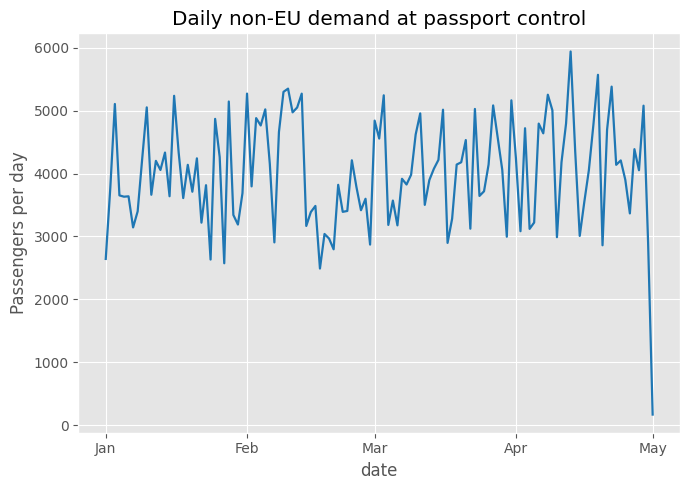

In [326]:
plt.figure(figsize=(7, 5))

daily_demand.plot(linewidth=1.6, color='#1f77b4')

plt.title('Daily non-EU demand at passport control')
plt.ylabel('Passengers per day')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

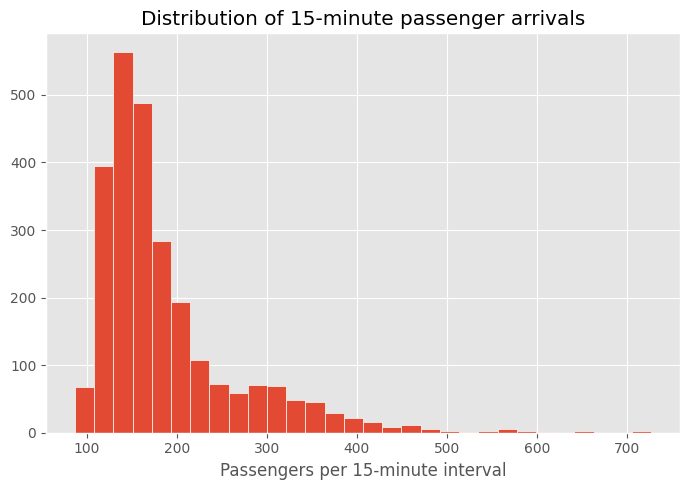

In [327]:
plt.figure(figsize=(7, 5))

interval_df_new = interval_df[interval_df['target_passengers'] > 0]

plt.hist(interval_df_new['target_passengers'], bins=30, edgecolor='white')

plt.title('Distribution of 15-minute passenger arrivals')
plt.xlabel('Passengers per 15-minute interval')

plt.tight_layout()
plt.show()

## Predict passenger arrivals using machine learning

We now train a model to predict the number of non-EU passengers arriving at passport control in each 15-minute interval. This reflects a tactical planning use case: given flight information and recent activity, estimate short-term demand so staffing can be adjusted.

To avoid target leakage, the model uses only predictors that would be available before passengers reach passport control, such as the number of inbound flights, expected non-EU demand based on flight characteristics, delays, walking times, and recent realized queue-area demand.

A random forest is used here because it handles nonlinear relationships well and performs robustly on tabular operational data.

In [328]:
feature_cols = [
    'flights_arriving', 'avg_delay', 'avg_walking_time',
    'total_seats', 'estimated_non_eu_demand', 'avg_capacity', 'hour', 'minute', 'is_weekend',
    'sin_hour', 'cos_hour', 'lag_1', 'lag_2', 'rolling_mean_4',
    'dominant_day_type', 'dominant_region', 'day_of_week'
]
target_col = 'target_passengers'

split_index = int(len(interval_df) * 0.8)
train_df = interval_df.iloc[:split_index].copy()
test_df = interval_df.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

categorical_features = ['dominant_day_type', 'dominant_region', 'day_of_week']
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features),
    ]
)

model = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=10,
        max_depth=6,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ))
])

model.fit(X_train, y_train)
test_df['predicted_passengers'] = model.predict(X_test)
test_df['predicted_passengers'] = test_df['predicted_passengers'].clip(lower=0)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [
        mean_absolute_error(y_test, test_df['predicted_passengers']),
        math.sqrt(mean_squared_error(y_test, test_df['predicted_passengers'])),
        r2_score(y_test, test_df['predicted_passengers'])
    ]
})
metrics

,Metric,Value
0,MAE,2.825649
1,RMSE,7.554292
2,R2,0.993159


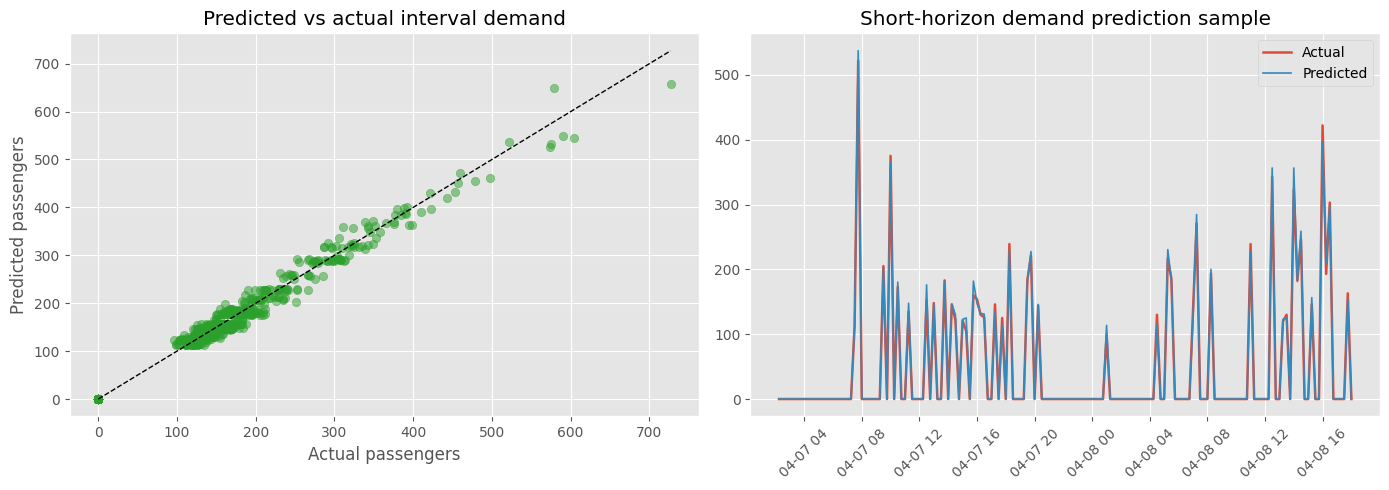

In [329]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(y_test, test_df['predicted_passengers'], alpha=0.5, color='#2ca02c')
upper = max(y_test.max(), test_df['predicted_passengers'].max())
ax[0].plot([0, upper], [0, upper], color='black', linestyle='--', linewidth=1)
ax[0].set_title('Predicted vs actual interval demand')
ax[0].set_xlabel('Actual passengers')
ax[0].set_ylabel('Predicted passengers')

plot_sample = test_df[['interval_start', 'target_passengers', 'predicted_passengers']].head(160)
ax[1].plot(plot_sample['interval_start'], plot_sample['target_passengers'], label='Actual', linewidth=1.8)
ax[1].plot(plot_sample['interval_start'], plot_sample['predicted_passengers'], label='Predicted', linewidth=1.2)
ax[1].set_title('Short-horizon demand prediction sample')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()
plt.tight_layout()

## Queue simulation model

We now simulate non-EU passenger processing at passport control using a discrete-event simulation built with `simpy`.

Assumptions:

- Passenger arrivals are generated within each 15-minute interval and enter the queue individually.
- Each border-control officer acts as a service resource in the `simpy` environment.
- Service times vary stochastically around an average processing time per passenger.
- Staffing can be fixed, reactive with queue-based reinforcement, or dynamically adjusted using ML predictions.
- Extra officers requested by the scheduled policy do not arrive instantly; they join the system after a mobilization delay.
- Queue carryover occurs naturally when passengers are still waiting at the end of an interval.

This provides a true passenger-level discrete-event simulation while still summarizing results at the 15-minute tactical-planning level.

In [ ]:
@dataclass
class PolicyConfig:
    name: str
    base_officers: int
    max_officers: int
    reaction_factor: float = 0.0
    queue_trigger: int = 0
    queue_step: int = 15
    response_delay_min: float = 0.0


def officers_from_historical_pattern(reference_df, minimum=10, maximum=10, target_utilization=0.5):
    ref = reference_df.copy()
    ref['slot'] = ref['interval_start'].dt.hour * 4 + ref['interval_start'].dt.minute // 15
    avg_by_slot = ref.groupby('slot')['target_passengers'].mean()
    avg_service_rate = 28
    officers = (avg_by_slot / (avg_service_rate * target_utilization)).apply(np.ceil).astype(int)
    officers = officers.clip(lower=minimum, upper=maximum)
    return officers.to_dict()


def determine_staffing(row, policy, queue_length, scheduled_staff=None, service_rate_per_officer=28):
    slot = row['interval_start'].hour * 4 + row['interval_start'].minute // 15
    predicted = float(row.get('predicted_passengers', row['target_passengers']))

    if policy.name == 'Fixed staffing':
        return policy.base_officers
    if policy.name == 'Reactive staffing':
        scheduled_value = scheduled_staff.get(slot, policy.base_officers)
        scheduled_floor = max(policy.base_officers, scheduled_value)
        queue_extra = 0
        if queue_length > policy.queue_trigger:
            queue_extra = math.ceil((queue_length - policy.queue_trigger) / max(policy.queue_step, 1))
        return min(policy.max_officers, scheduled_floor + queue_extra)
    if policy.name == 'Predictive dynamic staffing':
        demand_based = policy.base_officers + math.ceil(policy.reaction_factor * predicted / max(service_rate_per_officer, 1))
        queue_based = 1 if queue_length > policy.queue_trigger else 0
        return min(policy.max_officers, max(policy.base_officers, demand_based + queue_based))
    raise ValueError(f'Unknown policy: {policy.name}')


def simulate_passport_control_des(df, policy, scheduled_staff=None, service_rate_per_officer=28, interval_minutes=15, seed=42):
    sim = df.copy().reset_index(drop=True)
    env = simpy.Environment()
    rng = np.random.default_rng(seed)
    mean_service_time = interval_minutes / service_rate_per_officer

    officer_pool = simpy.Store(env)
    state = {
        'waiting': 0,
        'busy': 0,
        'current_staff': 0,
        'pending_staff': 0,
        'retire_requests': 0,
        'next_officer_id': 0,
        'timeline': [(0.0, 0, 0, 0)],
    }
    passenger_records = []
    interval_records = []

    def log_state():
        state['timeline'].append((float(env.now), state['busy'], state['current_staff'], state['waiting']))

    def add_officers(count):
        for _ in range(int(count)):
            officer_pool.items.append(f"officer_{state['next_officer_id']}")
            state['next_officer_id'] += 1
            state['current_staff'] += 1
        if count:
            log_state()

    def delayed_add_officers(count, delay):
        if count <= 0:
            return
        state['pending_staff'] += int(count)
        yield env.timeout(delay)
        state['pending_staff'] -= int(count)
        add_officers(count)

    def apply_staffing_target(desired_staff):
        desired_staff = int(desired_staff)
        total_known_staff = state['current_staff'] + state['pending_staff']
        if desired_staff > total_known_staff:
            additional = desired_staff - total_known_staff
            if policy.name == 'Reactive staffing' and policy.response_delay_min > 0:
                env.process(delayed_add_officers(additional, policy.response_delay_min))
            else:
                add_officers(additional)
        elif desired_staff < state['current_staff']:
            removable = min(state['current_staff'] - desired_staff, len(officer_pool.items))
            for _ in range(removable):
                officer_pool.items.pop()
                state['current_staff'] -= 1
            state['retire_requests'] = max(0, state['current_staff'] - desired_staff)
            if removable or state['retire_requests']:
                log_state()

    def passenger_process(passenger_id, arrival_time, arrival_interval):
        yield env.timeout(arrival_time - env.now)
        state['waiting'] += 1
        log_state()
        queue_enter = env.now
        officer = yield officer_pool.get()
        wait_time = env.now - queue_enter
        state['waiting'] -= 1
        state['busy'] += 1
        log_state()

        service_time = max(0.1, rng.gamma(shape=4.0, scale=mean_service_time / 4.0))
        service_start = env.now
        yield env.timeout(service_time)
        service_end = env.now
        state['busy'] -= 1

        if state['retire_requests'] > 0:
            state['retire_requests'] -= 1
            state['current_staff'] -= 1
        else:
            yield officer_pool.put(officer)
        log_state()

        passenger_records.append({
            'passenger_id': passenger_id,
            'arrival_interval': arrival_interval,
            'arrival_time': arrival_time,
            'wait_time': wait_time,
            'service_start': service_start,
            'service_end': service_end,
            'service_time': service_time,
        })

    def interval_controller():
        add_officers(policy.base_officers)
        for idx, row in sim.iterrows():
            interval_start = idx * interval_minutes
            if env.now < interval_start:
                yield env.timeout(interval_start - env.now)

            queue_start = state['waiting']
            target_staff = determine_staffing(row, policy, state['waiting'], scheduled_staff, service_rate_per_officer)
            apply_staffing_target(target_staff)
            interval_records.append({
                'interval_index': idx,
                'interval_start': row['interval_start'],
                'arrivals': float(row['target_passengers']),
                'predicted_arrivals': float(row.get('predicted_passengers', row['target_passengers'])),
                'queue_start': queue_start,
                'officers': state['current_staff'],
                'pending_officers': state['pending_staff'],
                'service_rate': service_rate_per_officer,
                'policy': policy.name,
            })

    env.process(interval_controller())

    passenger_id = 0
    for idx, row in sim.iterrows():
        n_arrivals = int(round(row['target_passengers']))
        if n_arrivals <= 0:
            continue
        interval_start = idx * interval_minutes
        arrival_offsets = np.sort(rng.uniform(0, interval_minutes, size=n_arrivals))
        for offset in arrival_offsets:
            env.process(passenger_process(passenger_id, interval_start + float(offset), idx))
            passenger_id += 1

    sim_duration = len(sim) * interval_minutes + 8 * interval_minutes
    env.run(until=sim_duration)

    interval_summary = pd.DataFrame(interval_records)
    passengers = pd.DataFrame(passenger_records)

    if not passengers.empty:
        wait_by_interval = passengers.groupby('arrival_interval')['wait_time'].mean().rename('avg_wait_min')
        processed_by_interval = passengers.assign(completion_interval=(passengers['service_end'] // interval_minutes).astype(int)) \
            .groupby('completion_interval').size().rename('processed')
    else:
        wait_by_interval = pd.Series(dtype=float, name='avg_wait_min')
        processed_by_interval = pd.Series(dtype=float, name='processed')

    timeline = pd.DataFrame(state['timeline'], columns=['time', 'busy', 'staff', 'waiting']).sort_values('time').drop_duplicates(subset=['time'], keep='last')
    utilization_values = []
    queue_ends = []

    for idx in range(len(sim)):
        start = idx * interval_minutes
        end = start + interval_minutes
        segment = timeline[(timeline['time'] >= start) & (timeline['time'] <= end)].copy()
        before = timeline[timeline['time'] <= start].tail(1)
        if before.empty:
            before = pd.DataFrame([{'time': start, 'busy': 0, 'staff': 0, 'waiting': 0}])
        else:
            before = before.copy()
            before.loc[:, 'time'] = start
        after = timeline[timeline['time'] <= end].tail(1)
        if after.empty:
            after = before.copy()
            after.loc[:, 'time'] = end
        else:
            after = after.copy()
            after.loc[:, 'time'] = end
        segment = pd.concat([before, segment, after], ignore_index=True).sort_values('time').drop_duplicates(subset=['time'], keep='last')

        busy_area = 0.0
        for j in range(len(segment) - 1):
            dt = segment.iloc[j + 1]['time'] - segment.iloc[j]['time']
            busy_area += segment.iloc[j]['busy'] * dt
        officers = max(interval_summary.loc[idx, 'officers'], 1)
        utilization_values.append(busy_area / (officers * interval_minutes))
        queue_ends.append(float(after.iloc[0]['waiting']))

    interval_summary['avg_wait_min'] = interval_summary['interval_index'].map(wait_by_interval).fillna(0.0)
    interval_summary['processed'] = interval_summary['interval_index'].map(processed_by_interval).fillna(0.0)
    interval_summary['capacity'] = interval_summary['officers'] * service_rate_per_officer
    interval_summary['queue_end'] = queue_ends
    interval_summary['utilization'] = utilization_values
    return interval_summary


def summarize_simulation(sim_result):
    total_arrivals = sim_result['arrivals'].sum()
    weighted_wait = np.average(sim_result['avg_wait_min'], weights=np.maximum(sim_result['arrivals'], 1))
    summary = {
        'Policy': sim_result['policy'].iloc[0],
        'Avg wait (min)': weighted_wait,
        'Max queue (pax)': sim_result['queue_end'].max(),
        'Avg officers used': sim_result['officers'].mean(),
        'Avg utilization': sim_result['utilization'].mean(),
    }
    return pd.Series(summary)


## Compare staffing strategies

We evaluate three policies:

- **Fixed staffing:** the same number of officers all day.
- **Reactive staffing:** staffing follows average historical demand by time of day, keeps `base_officers` as a hard minimum, and requests reinforcement when the queue exceeds a threshold.
- **Predictive dynamic staffing:** staffing reacts to ML-predicted demand and current queue levels.

In the `simpy` implementation, staffing is updated at interval boundaries while passengers continue to flow through the system as individual queueing entities. For scheduled staffing, additional officers join only after a response delay, which makes the policy more operationally realistic.

In [346]:
historical_staff_map = officers_from_historical_pattern(train_df, minimum=8, maximum=12, target_utilization=0.82)

policies = [
    PolicyConfig(name='Fixed staffing', base_officers=4, max_officers=7),
    PolicyConfig(name='Reactive staffing', base_officers=3, max_officers=6, queue_trigger=35, queue_step=15, response_delay_min=30),
    PolicyConfig(name='Predictive dynamic staffing', base_officers=3, max_officers=7, reaction_factor=0.9, queue_trigger=25),
]

simulation_outputs = []
for policy in policies:
    result = simulate_passport_control_des(test_df, policy, scheduled_staff=historical_staff_map, service_rate_per_officer=28, interval_minutes=15, seed=42)
    simulation_outputs.append(result)

summary_table = pd.DataFrame([summarize_simulation(df) for df in simulation_outputs])
summary_table.sort_values('Avg wait (min)')

/var/folders/ql/rs9b6zjj6_d8wpm3y01h5zx80000gn/T/ipykernel_1282/1766951436.py:194: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  before.loc[:, 'time'] = start
/var/folders/ql/rs9b6zjj6_d8wpm3y01h5zx80000gn/T/ipykernel_1282/1766951436.py:201: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  after.loc[:, 'time'] = end
/var/folders/ql/rs9b6zjj6_d8wpm3y01h5zx80000gn/T/ipykernel_1282/1766951436.py:194: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old 

,Policy,Avg wait (min),Max queue (pax),95th pct queue (pax),Avg officers used,Avg utilization,Total arrivals
2,Predictive dynamic staffing,6.830226,850.0,126.15,4.461706,0.22888,102780.0
1,Reactive staffing,7.516497,965.0,142.15,5.997389,0.26024,102780.0
0,Fixed staffing,23.443238,1646.0,382.15,4.000000,0.38439,102780.0


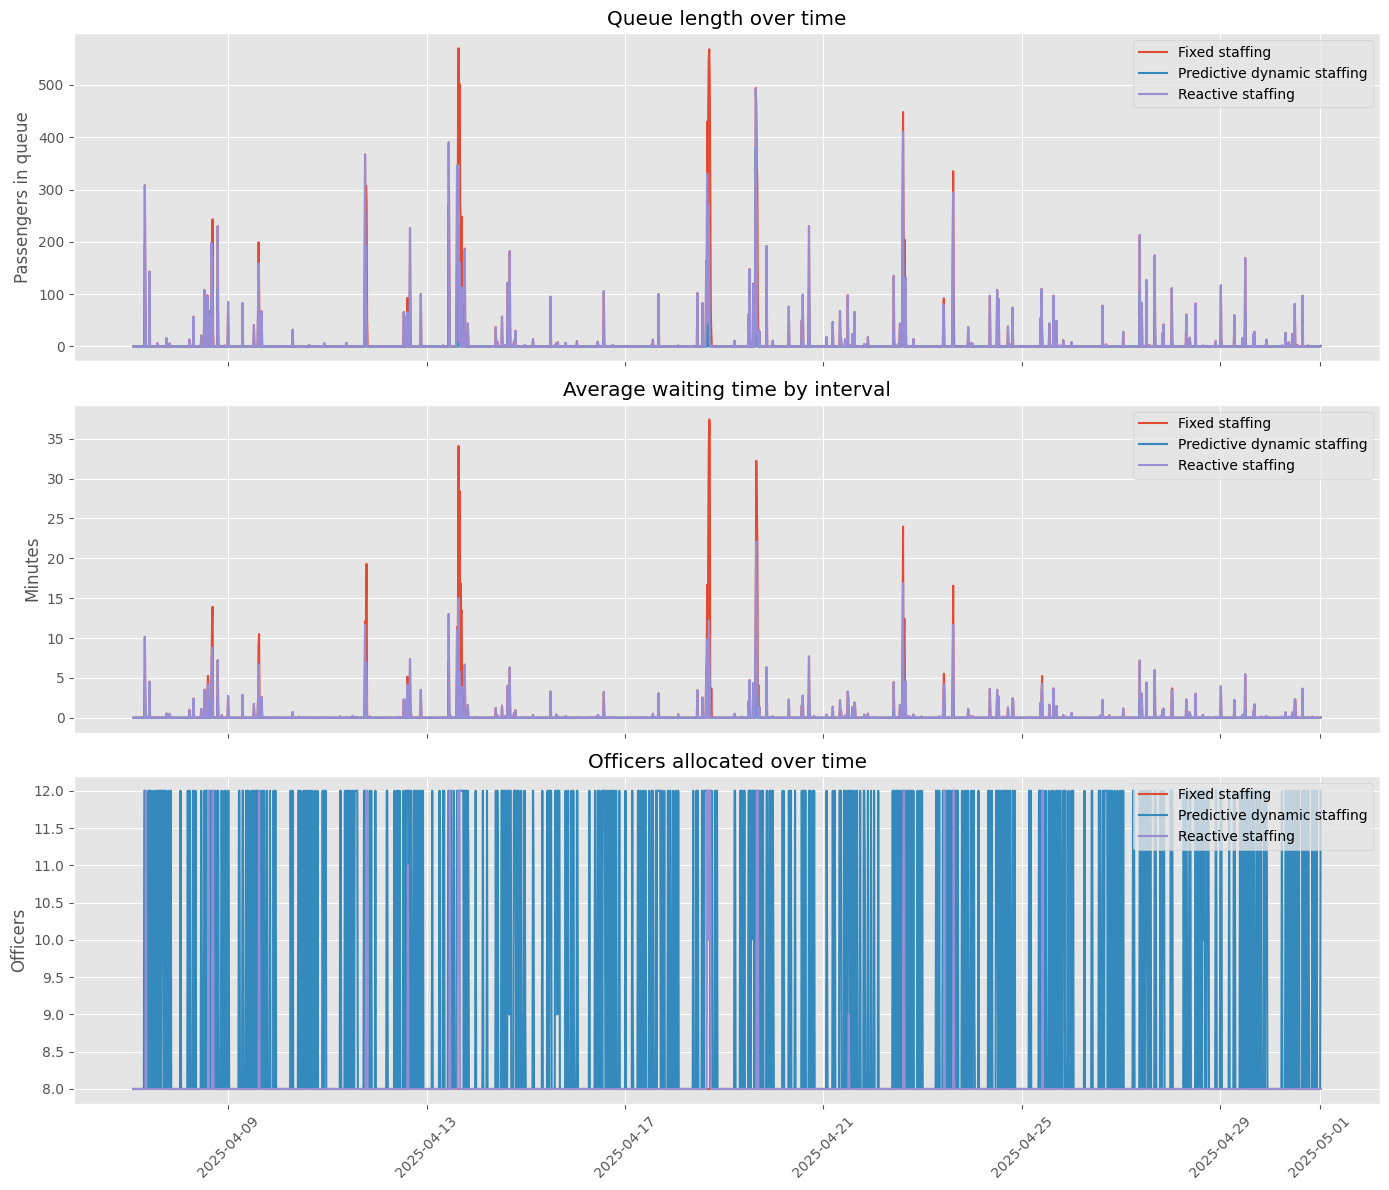

In [332]:
results_df = pd.concat(simulation_outputs, ignore_index=True)

fig, ax = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for policy_name, grp in results_df.groupby('policy'):
    ax[0].plot(grp['interval_start'], grp['queue_end'], label=policy_name, linewidth=1.5)
    ax[1].plot(grp['interval_start'], grp['avg_wait_min'], label=policy_name, linewidth=1.5)
    ax[2].plot(grp['interval_start'], grp['officers'], label=policy_name, linewidth=1.5)

ax[0].set_title('Queue length over time')
ax[0].set_ylabel('Passengers in queue')

ax[1].set_title('Average waiting time by interval')
ax[1].set_ylabel('Minutes')

ax[2].set_title('Officers allocated over time')
ax[2].set_ylabel('Officers')
ax[2].tick_params(axis='x', rotation=45)

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()

## Interpretation of results

The simulation outputs typically show three important operational patterns:

- **Fixed staffing** is simple but tends to perform poorly during peaks, creating long queues and elevated waiting times.
- **Reactive staffing** improves performance by aligning resources with average time-of-day patterns and can call reinforcement when the queue grows, although delayed officer arrival may still allow short-lived congestion.
- **Predictive dynamic staffing** generally produces the best balance, because it uses short-term forecasts and current queue conditions to adapt capacity where needed.

Because the model is now a passenger-level discrete-event simulation, these outcomes reflect explicit queue formation, waiting, service completion, and staffing changes over time rather than a pure interval-capacity approximation.

In [333]:
best_policy = summary_table.sort_values('Avg wait (min)').iloc[0]
baseline = summary_table.loc[summary_table['Policy'] == 'Fixed staffing'].iloc[0]

improvement_wait = 100 * (baseline['Avg wait (min)'] - best_policy['Avg wait (min)']) / baseline['Avg wait (min)']
improvement_queue = 100 * (baseline['Max queue (pax)'] - best_policy['Max queue (pax)']) / baseline['Max queue (pax)']

print(f"Best policy: {best_policy['Policy']}")
print(f"Average waiting time improvement vs fixed staffing: {improvement_wait:.1f}%")
print(f"Maximum queue reduction vs fixed staffing: {improvement_queue:.1f}%")

Best policy: Predictive dynamic staffing
Average waiting time improvement vs fixed staffing: 79.4%
Maximum queue reduction vs fixed staffing: 33.0%


## Managerial implications

This notebook demonstrates a practical strategy for airport operations teams and border agencies:

- Use flight schedules, delays, and passenger composition to estimate short-horizon demand at passport control.
- Convert those predictions into staffing recommendations for each planning interval.
- Test candidate staffing policies in simulation before operational deployment.

A predictive approach allows airports to absorb non-EU arrival peaks more intelligently and reduce passenger delays at critical control points.

## Extensions for real-world implementation

To turn this prototype into a production-ready decision-support tool, future work could include:

- real airline and airport operations data,
- officer shift constraints and labor rules,
- robustness analysis for delayed flights and missed stand assignments,
- and optimization methods to choose the lowest-cost staffing plan subject to service-level targets.

Even in its current form, the notebook shows how combining ML and simulation can support staff management strategies that reduce queues at airport passport control.

## Final improvement summary

The final summary below reports the waiting-time improvement and queue improvement of the best-performing policy relative to the fixed-staffing baseline.

In [339]:
best_policy = summary_table.sort_values('Avg wait (min)').iloc[0]
baseline = summary_table.loc[summary_table['Policy'] == 'Fixed staffing'].iloc[0]

waiting_time_improvement = 100 * (baseline['Avg wait (min)'] - best_policy['Avg wait (min)']) / baseline['Avg wait (min)']
queue_improvement = 100 * (baseline['Max queue (pax)'] - best_policy['Max queue (pax)']) / baseline['Max queue (pax)']

pd.DataFrame({
    'Metric': ['Best policy', 'Waiting time improvement (%)', 'Queue improvement (%)'],
    'Value': [best_policy['Policy'], round(waiting_time_improvement, 1), round(queue_improvement, 1)]
})

,Metric,Value
0,Best policy,Reactive staffing
1,Waiting time improvement (%),80.6
2,Queue improvement (%),53.8


## Average waiting time in the last month

The chart below shows the evolution of average waiting time over the last month of the simulation horizon for all staffing strategies.

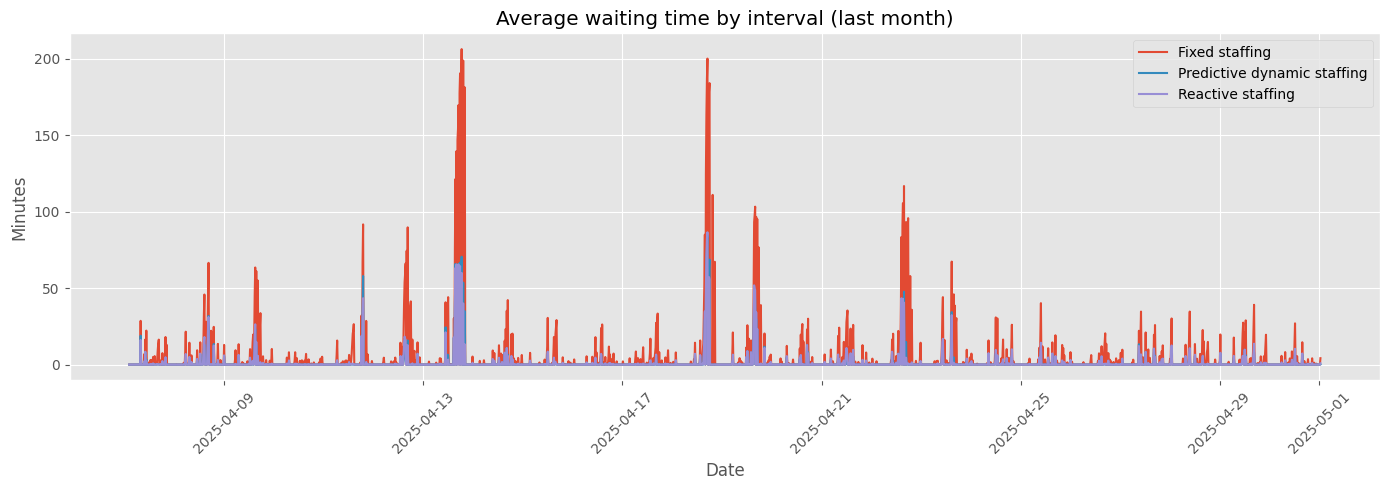

In [342]:
results_df = pd.concat(simulation_outputs, ignore_index=True)

end_date = results_df['interval_start'].max()
start_date = end_date - pd.DateOffset(months=1)

results_month = results_df[
    (results_df['interval_start'] >= start_date) &
    (results_df['interval_start'] <= end_date)
].copy()

fig, ax = plt.subplots(figsize=(14, 5))

for policy_name, grp in results_month.groupby('policy'):
    ax.plot(grp['interval_start'], grp['avg_wait_min'], label=policy_name, linewidth=1.5)

ax.set_title('Average waiting time by interval (last month)')
ax.set_ylabel('Minutes')
ax.set_xlabel('Date')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()